<p style="font-size:300%; background-color:#ffe6f0; color:#0044cc; text-align:center; line-height:80px; margin:0; padding:0;">
  <b>Introducción al Procesamiento de Lenguaje Natural</b>
</p>

<p style="font-size:240%; background-color:#ffe6f0; color:#cc0000; text-align:center; line-height:60px; margin:0; padding:0;">
  <b>Técnicas de Inteligencia Artificial</b>
</p>

<p style="font-size:200%; text-align:center; line-height:40px; margin:0;">
  <br><b>Prof. Flavio Prieto</b>
</p>

<p style="font-size:160%; text-align:center; line-height:25px; margin:0;">
  email: <a href="mailto:faprietoo@unal.edu.co">faprietoo@unal.edu.co</a>
</p>

<p style="font-size:180%; text-align:center; line-height:30px; margin:0;">
  <br><b>DEPARTAMENTO DE INGENIERÍA MECÁNICA Y MECATRÓNICA</b>
</p>

<p style="font-size:180%; text-align:center; line-height:30px; margin:0;">
  Facultad de Ingeniería
</p>

<p style="font-size:160%; text-align:center; line-height:30px; margin:0;">
  Universidad Nacional de Colombia – Sede Bogotá
</p>

<div style="text-align:center; margin-top:20px; margin-bottom:10px;">
  <img src="Fig/Escudo_UN.png" alt="Escudo UNAL" width="90" style="border:none;">
</div>

<p style="font-size:160%; text-align:center; line-height:30px; margin:0;">
  10 de febrero de 2026
</p>

# Procesamiento de Lenguaje Natural con NLTK

## Tomado de:


> <span style="background-color: yellow;">**Natural Language Processing with NLTK in Python:**</span>
> <span style="background-color: yellow;">https://realpython.com/nltk-nlp-python/</span>


In [410]:
#!python -m pip install nltk==3.5

In [411]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /home/sergio/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/sergio/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/sergio/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

# Tokenización de Texto

In [412]:
# Importar NLTK y los tokenizadores necesarios
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize

### Crear una cadena de texto para tokenizar

In [413]:
example_string = """
Muad'Dib learned rapidly because his first training was in how to learn. And the first lesson of all was the basic trust that he could learn. It's shocking to find how many people do not believe they can learn, and how many more believe learning to be difficult."""

In [414]:
print(example_string)


Muad'Dib learned rapidly because his first training was in how to learn. And the first lesson of all was the basic trust that he could learn. It's shocking to find how many people do not believe they can learn, and how many more believe learning to be difficult.


### Use **sent_tokenize()** para dividir example_string en oraciones.

In [415]:
S = sent_tokenize(example_string)
print(S)
print("Tamaño",len(S))
S = sent_tokenize(example_string)
for i, sentence in enumerate(S):
    print(f"Oración {i+1}: {sentence}")

["\nMuad'Dib learned rapidly because his first training was in how to learn.", 'And the first lesson of all was the basic trust that he could learn.', "It's shocking to find how many people do not believe they can learn, and how many more believe learning to be difficult."]
Tamaño 3
Oración 1: 
Muad'Dib learned rapidly because his first training was in how to learn.
Oración 2: And the first lesson of all was the basic trust that he could learn.
Oración 3: It's shocking to find how many people do not believe they can learn, and how many more believe learning to be difficult.


### Use **word_tokenize** para tokenizar por palabra

In [416]:
W = word_tokenize(example_string)
print(W)

["Muad'Dib", 'learned', 'rapidly', 'because', 'his', 'first', 'training', 'was', 'in', 'how', 'to', 'learn', '.', 'And', 'the', 'first', 'lesson', 'of', 'all', 'was', 'the', 'basic', 'trust', 'that', 'he', 'could', 'learn', '.', 'It', "'s", 'shocking', 'to', 'find', 'how', 'many', 'people', 'do', 'not', 'believe', 'they', 'can', 'learn', ',', 'and', 'how', 'many', 'more', 'believe', 'learning', 'to', 'be', 'difficult', '.']


In [417]:
W = word_tokenize(S[0])
print(W)

["Muad'Dib", 'learned', 'rapidly', 'because', 'his', 'first', 'training', 'was', 'in', 'how', 'to', 'learn', '.']


### Otro ejemplo

In [418]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

# Descargar recursos necesarios
nltk.download('punkt')
nltk.download('punkt_tab')

# Cadena de texto de ejemplo (cita de Dune)
quote = "I must not fear. Fear is the mind-killer. Fear is the little-death that brings total obliteration."

# Tokenización por oración
sentences = sent_tokenize(quote)
print("Tokenización por oración:")
print(sentences)

# Tokenización por palabra
words = word_tokenize(quote)
print("\nTokenización por palabra:")
print(words)


Tokenización por oración:
['I must not fear.', 'Fear is the mind-killer.', 'Fear is the little-death that brings total obliteration.']

Tokenización por palabra:
['I', 'must', 'not', 'fear', '.', 'Fear', 'is', 'the', 'mind-killer', '.', 'Fear', 'is', 'the', 'little-death', 'that', 'brings', 'total', 'obliteration', '.']


[nltk_data] Downloading package punkt to /home/sergio/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/sergio/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Filtrado de Stop Words:


In [419]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Texto de ejemplo
example_text = "This is a simple example demonstrating stop word filtering."

# Obtener lista de stop words en inglés
stop_words = set(stopwords.words('english'))

# Tokenizar y filtrar
words = word_tokenize(example_text)
filtered_words = [word for word in words if word.lower() not in stop_words]

print(filtered_words)


['simple', 'example', 'demonstrating', 'stop', 'word', 'filtering', '.']


In [420]:
# Nuevo texto de ejemplo
text = "Natural language processing allows machines to understand human language in a meaningful way."

print("\nTexto antes del filtrado:")
print(text)
# Lista de stop words
stop_words = set(stopwords.words('english'))

# Tokenización y filtrado
tokens = word_tokenize(text)
filtered = [word for word in tokens if word.lower() not in stop_words]

print("\nPalabras después del filtrado:")
print(filtered)



Texto antes del filtrado:
Natural language processing allows machines to understand human language in a meaningful way.

Palabras después del filtrado:
['Natural', 'language', 'processing', 'allows', 'machines', 'understand', 'human', 'language', 'meaningful', 'way', '.']


In [421]:
worf_quote = "Sir, I protest. I am not a merry man!"
words_in_quote = word_tokenize(worf_quote)
words_in_quote

filtered = [word for word in words_in_quote if word.lower() not in stop_words]

print("\nPalabras después del filtrado:")
print(filtered)


Palabras después del filtrado:
['Sir', ',', 'protest', '.', 'merry', 'man', '!']


## Filtrado de palabras usando un conjunto de Stop Words

Ya se cuenta con una lista de palabras extraídas de `worf_quote`.  
El siguiente paso consiste en crear un conjunto de *stop words* en inglés para filtrar aquellas que no aportan significado relevante.


In [422]:
stop_words = set(stopwords.words("english"))
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

### Crear una lista vacía para almacenar las palabras filtradas

In [423]:
filtered_list = []

### Iteración con filtrado y uso de `.casefold()`

In [424]:
for word in words_in_quote:
    if word.casefold() not in stop_words:
        filtered_list.append(word)

# Mostrar el resultado
print("Palabras que pasaron el filtro (ignorando mayúsculas/minúsculas):\n")
print(filtered_list)

Palabras que pasaron el filtro (ignorando mayúsculas/minúsculas):

['Sir', ',', 'protest', '.', 'merry', 'man', '!']


### Alternativa: Usar una List Comprehension

In [425]:
# Usar list comprehension para filtrar directamente
filtered_list = [word for word in words_in_quote if word.casefold() not in stop_words]

# Mostrar el resultado
print("Palabras filtradas con list comprehension:\n")
print(filtered_list)


Palabras filtradas con list comprehension:

['Sir', ',', 'protest', '.', 'merry', 'man', '!']


### Personalizar la lista de Stop Words

In [426]:
# Cargar lista estándar de stop words en inglés
stop_words = set(stopwords.words('english'))

# Eliminar palabras que se quieren conservar en el análisis
stop_words.discard('not')
stop_words.discard('i')

In [427]:
# Usar list comprehension para filtrar directamente
filtered_list = [word for word in words_in_quote if word.casefold() not in stop_words]

# Mostrar el resultado
print("Palabras filtradas con list comprehension:\n")
print(filtered_list)


Palabras filtradas con list comprehension:

['Sir', ',', 'I', 'protest', '.', 'I', 'not', 'merry', 'man', '!']


# Stemming

In [428]:
from nltk.stem import PorterStemmer

# Crear un objeto PorterStemmer
stemmer = PorterStemmer()

# Ejemplo de palabras para hacer stemming
words = ["running", "runner", "ran", "easily", "happiness"]

# Aplicar stemming
stemmed_words = [stemmer.stem(word) for word in words]

# Mostrar el resultado
print("Palabras después del stemming:\n")
print(stemmed_words)


Palabras después del stemming:

['run', 'runner', 'ran', 'easili', 'happi']


### OTRO EJEMPLO

In [429]:
string_for_stemming = """ The crew of the USS Discovery discovered many discoveries. 
Discovering is what explorers do."""
words = word_tokenize(string_for_stemming)
print(words)

['The', 'crew', 'of', 'the', 'USS', 'Discovery', 'discovered', 'many', 'discoveries', '.', 'Discovering', 'is', 'what', 'explorers', 'do', '.']


In [430]:
stemmed_words = [stemmer.stem(word) for word in words]

# Mostrar el resultado
print("Palabras después del stemming:\n")
print(stemmed_words)


Palabras después del stemming:

['the', 'crew', 'of', 'the', 'uss', 'discoveri', 'discov', 'mani', 'discoveri', '.', 'discov', 'is', 'what', 'explor', 'do', '.']


# Etiquetado de Partes de la Oración (POS Tagging)

In [431]:
import nltk
from nltk.tokenize import word_tokenize

# Descargar recursos necesarios
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('tagsets_json')

[nltk_data] Downloading package punkt to /home/sergio/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/sergio/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/sergio/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets_json to
[nltk_data]     /home/sergio/nltk_data...
[nltk_data]   Package tagsets_json is already up-to-date!


True

In [432]:
# Famosa cita de Carl Sagan
sagan_quote = """
If you wish to make an apple pie from scratch,
you must first invent the universe.
"""

words_in_sagan_quote = word_tokenize(sagan_quote)

tagged_words = nltk.pos_tag(words_in_sagan_quote)

print(tagged_words)

[('If', 'IN'), ('you', 'PRP'), ('wish', 'VBP'), ('to', 'TO'), ('make', 'VB'), ('an', 'DT'), ('apple', 'NN'), ('pie', 'NN'), ('from', 'IN'), ('scratch', 'NN'), (',', ','), ('you', 'PRP'), ('must', 'MD'), ('first', 'VB'), ('invent', 'VB'), ('the', 'DT'), ('universe', 'NN'), ('.', '.')]


## ¿Qué significan las etiquetas?

Cada etiqueta corresponde a una categoría gramatical del estándar **Penn Treebank**:

- `'NN'` → Noun (sustantivo)
- `'VB'` → Verb base form (verbo en infinitivo)
- `'DT'` → Determiner (determinante/artículo)
- `'PRP'` → Personal pronoun (pronombre personal)
- ...

Para ver la lista completa con descripciones detalladas:


In [433]:
nltk.download('tagsets')  # Solo es necesario una vez
nltk.help.upenn_tagset()


$: dollar
    $ -$ --$ A$ C$ HK$ M$ NZ$ S$ U.S.$ US$
'': closing quotation mark
    ' ''
(: opening parenthesis
    ( [ {
): closing parenthesis
    ) ] }
,: comma
    ,
--: dash
    --
.: sentence terminator
    . ! ?
:: colon or ellipsis
    : ; ...
CC: conjunction, coordinating
    & 'n and both but either et for less minus neither nor or plus so
    therefore times v. versus vs. whether yet
CD: numeral, cardinal
    mid-1890 nine-thirty forty-two one-tenth ten million 0.5 one forty-
    seven 1987 twenty '79 zero two 78-degrees eighty-four IX '60s .025
    fifteen 271,124 dozen quintillion DM2,000 ...
DT: determiner
    all an another any both del each either every half la many much nary
    neither no some such that the them these this those
EX: existential there
    there
FW: foreign word
    gemeinschaft hund ich jeux habeas Haementeria Herr K'ang-si vous
    lutihaw alai je jour objets salutaris fille quibusdam pas trop Monte
    terram fiche oui corporis ...
IN: preposition or

[nltk_data] Downloading package tagsets to /home/sergio/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!


### ¿Cómo se comporta el POS Tagging con texto sin sentido?

In [434]:
# Fragmento del poema Jabberwocky
jabberwocky_excerpt = """
'Twas brillig, and the slithy toves did gyre and gimble in the wabe:
all mimsy were the borogoves, and the mome raths outgrabe."""

# Tokenizar palabras
words_in_excerpt = word_tokenize(jabberwocky_excerpt)

# Etiquetar partes de la oración
tagged_excerpt = nltk.pos_tag(words_in_excerpt)

# Mostrar el resultado
for word, tag in tagged_excerpt:
    print(f"{word:12} → {tag}")

'Twas        → CD
brillig      → NN
,            → ,
and          → CC
the          → DT
slithy       → JJ
toves        → NNS
did          → VBD
gyre         → NN
and          → CC
gimble       → JJ
in           → IN
the          → DT
wabe         → NN
:            → :
all          → DT
mimsy        → NNS
were         → VBD
the          → DT
borogoves    → NNS
,            → ,
and          → CC
the          → DT
mome         → JJ
raths        → NNS
outgrabe     → RB
.            → .


# Lematización

In [435]:
# Para comenzar a lematizar palabras con NLTK, se debe importar el lematizador de WordNet:

from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /home/sergio/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [436]:
# Crear una instancia del lematizador
lemmatizer = WordNetLemmatizer()

In [437]:
# Ejemplo: lematizar sustantivos en plural

lemmatizer.lemmatize("scarves")

# A diferencia del stemming (que podría devolver 'scarv'),
# la lematización entrega una palabra completa y con sentido: 'scarf'.


'scarf'

In [438]:
# Lematizar una oración
string_for_lemmatizing = "The friends of DeSoto love scarves."

words = word_tokenize(string_for_lemmatizing)
print(words)

['The', 'friends', 'of', 'DeSoto', 'love', 'scarves', '.']


In [439]:
# Ahora se lematizan todas las palabras de la lista:
lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
print(lemmatized_words)

['The', 'friend', 'of', 'DeSoto', 'love', 'scarf', '.']


## Lematizar palabras con significado alejado de su lema

En algunos casos, una palabra puede parecer muy distinta a su lema. Por ejemplo:

In [440]:
lemmatizer.lemmatize("worst")
# Resultado: 'worst'

'worst'

En este caso, el lematizador asume por defecto que "worst" es un sustantivo (pos='n'), por lo que devuelve la misma palabra.

### Especificar la Categoría Gramatical (POS)nte

In [441]:

lemmatizer.lemmatize("worst", pos="a")
# Resultado: 'bad'


'bad'

# Chunking (Agrupación de frases)

## Chunking con NLTK

In [442]:
# Paso 1: Importar las herramientas necesarias

from nltk.tokenize import word_tokenize
import nltk

In [443]:
#Paso 2: Preparar el texto para análisis
#Se utiliza la siguiente cita de The Lord of the Rings:

lotr_quote = "It's a dangerous business, Frodo, going out your door."

# Paso 3: Tokenizar el texto
words_in_lotr_quote = word_tokenize(lotr_quote)
print(words_in_lotr_quote)

['It', "'s", 'a', 'dangerous', 'business', ',', 'Frodo', ',', 'going', 'out', 'your', 'door', '.']


In [444]:
# Paso 4: Etiquetar con POS tags
# Se obtiene una lista de tuplas, donde cada tupla contiene una palabra y su etiqueta gramatical correspondiente.

nltk.download("averaged_perceptron_tagger")
lotr_pos_tags = nltk.pos_tag(words_in_lotr_quote)
print(lotr_pos_tags)

[('It', 'PRP'), ("'s", 'VBZ'), ('a', 'DT'), ('dangerous', 'JJ'), ('business', 'NN'), (',', ','), ('Frodo', 'NNP'), (',', ','), ('going', 'VBG'), ('out', 'RP'), ('your', 'PRP$'), ('door', 'NN'), ('.', '.')]


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/sergio/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


### Definir una Gramática de Chunking

In [445]:
grammar = "NP: {<DT>?<JJ>*<NN>}"

### Crear y visualizar un Chunk Parser

In [446]:
chunk_parser = nltk.RegexpParser(grammar)


In [447]:
# Aplicar el parser

In [448]:
tree = chunk_parser.parse(lotr_pos_tags)

### Visualización del árbol de chunking

In [449]:
from nltk import Tree

In [450]:
tree = chunk_parser.parse(lotr_pos_tags)
tree.pretty_print()

                                            S                                                       
   _________________________________________|___________________________________________________     
  |      |     |      |      |      |       |        |      |            NP                     NP  
  |      |     |      |      |      |       |        |      |    ________|____________          |    
It/PRP 's/VBZ ,/, Frodo/NNP ,/, going/VBG out/RP your/PRP$ ./. a/DT dangerous/JJ business/NN door/NN



In [454]:
import matplotlib.pyplot as plt
from nltk.draw.util import CanvasFrame
from nltk.draw.tree import TreeWidget
from nltk import Tree

cf = CanvasFrame(width=800, height=600)   # <- importante
tc = TreeWidget(cf.canvas(), tree)

cf.add_widget(tc, 10, 10)
cf.print_to_file("./Notebook/tree.ps")
cf.destroy()

### Visualización del árbol

![Ejemplo](./fig/Notebook/Tree_1.png)

### Genera un árbol en formato .ps que se pasa a formato .png

# Chinking

In [466]:
# Se reutiliza la cita que se usó en la sección de **chunking**. 
# Ya se tiene una lista de tuplas que contienen cada una de las palabras de la cita
# junto con su etiqueta de parte de la oración (POS tag):

lotr_pos_tags

[('It', 'PRP'),
 ("'s", 'VBZ'),
 ('a', 'DT'),
 ('dangerous', 'JJ'),
 ('business', 'NN'),
 (',', ','),
 ('Frodo', 'NNP'),
 (',', ','),
 ('going', 'VBG'),
 ('out', 'RP'),
 ('your', 'PRP$'),
 ('door', 'NN'),
 ('.', '.')]

In [467]:
# El siguiente paso consiste en crear una gramática para determinar qué se debe incluir y excluir en los chunks.
# En esta ocasión, se utilizarán varias líneas debido a que se necesitarán más de una regla.
#Para esto, se emplearán comillas triples (""") para definir la gramática.

grammar = """
    Chunk: {<DT>?<NN.*>}      # Captura sustantivos, con o sin determinantes, sin incluir adjetivos
    Chink: {<JJ>}             # Excluye adjetivos (JJ)
"""


In [468]:
# Para crear un **chunk parser** con la gramática especificada, se usa el siguiente código:

chunk_parser = nltk.RegexpParser(grammar)
print(chunk_parser)

chunk.RegexpParser with 2 stages:
RegexpChunkParser with 1 rules:
    Captura sustantivos, con o sin determinantes, sin incluir adjetivos
      <ChunkRule: '<DT>?<NN.*>'>
RegexpChunkParser with 1 rules:
    Excluye adjetivos (JJ)   <ChunkRule: '<JJ>'>


In [469]:
# Luego, se puede aplicar el chunk parser a una oración utilizando la lista de tuplas que contienen las palabras
#de la cita y sus etiquetas de parte de la oración (POS tags):

tree = chunk_parser.parse(lotr_pos_tags)
print(tree)
tree.pretty_print()

(S
  It/PRP
  's/VBZ
  a/DT
  (Chink dangerous/JJ)
  (Chunk business/NN)
  ,/,
  (Chunk Frodo/NNP)
  ,/,
  going/VBG
  out/RP
  your/PRP$
  (Chunk door/NN)
  ./.)
                                       S                                                            
   ____________________________________|________________________________________________________     
  |      |     |    |   |      |       |        |      |     Chink        Chunk      Chunk    Chunk 
  |      |     |    |   |      |       |        |      |       |            |          |        |    
It/PRP 's/VBZ a/DT ,/, ,/, going/VBG out/RP your/PRP$ ./. dangerous/JJ business/NN Frodo/NNP door/NN



In [470]:
# Imprimir los chunks y sus componentes
for subtree in tree.subtrees():
    print(subtree)

(S
  It/PRP
  's/VBZ
  a/DT
  (Chink dangerous/JJ)
  (Chunk business/NN)
  ,/,
  (Chunk Frodo/NNP)
  ,/,
  going/VBG
  out/RP
  your/PRP$
  (Chunk door/NN)
  ./.)
(Chink dangerous/JJ)
(Chunk business/NN)
(Chunk Frodo/NNP)
(Chunk door/NN)


In [471]:
cf = CanvasFrame()
tc = TreeWidget(cf.canvas(), tree)
cf.add_widget(tc, 10, 10)  # coordenadas (x, y)
cf.print_to_file("./fig/Notebook/tree2.ps")  # Guarda como archivo
cf.destroy()

ValueError: invalid literal for int() with base 10: '10c'

In [ ]:
# import nltk
# from nltk import word_tokenize, pos_tag
# from nltk.chunk import RegexpParser

# # Definir la cita de LOTR
# lotr_quote = "It's a dangerous business, Frodo, going out your door."

# # Tokenización y etiquetado POS
# words_in_lotr_quote = word_tokenize(lotr_quote)
# lotr_pos_tags = pos_tag(words_in_lotr_quote)

# # Definir la gramática para los chunks
# grammar = """
#     Chunk: {<DT>?<NN.*>}      # Captura sustantivos, con o sin determinantes, sin incluir adjetivos
#     Chink: {<JJ>}             # Excluye adjetivos (JJ)
# """

# # Crear el parser con la gramática
# chunk_parser = RegexpParser(grammar)

# # Parsear el texto
# tree = chunk_parser.parse(lotr_pos_tags)
# print(tree)
# tree.pretty_print()

# Función para eliminar los "chinks" del árbol
def remove_chinks(tree):
    if isinstance(tree, nltk.Tree):
        if tree.label() == 'Chink':
            return None  # Excluir los "chinks"
        else:
            return nltk.Tree(tree.label(), [remove_chinks(child) for child in tree])
    else:
        return tree

# Eliminar los chinks del árbol
cleaned_tree = remove_chinks(tree)

# Imprimir el árbol limpio
print(cleaned_tree)
cleaned_tree.pretty_print()

(S
  It/PRP
  's/VBZ
  a/DT
  None
  (Chunk business/NN)
  ,/,
  (Chunk Frodo/NNP)
  ,/,
  going/VBG
  out/RP
  your/PRP$
  (Chunk door/NN)
  ./.)
                                    S                                                       
   _________________________________|___________________________________________________     
  |      |     |    |    |   |      |       |        |      |     Chunk      Chunk    Chunk 
  |      |     |    |    |   |      |       |        |      |       |          |        |    
It/PRP 's/VBZ a/DT None ,/, ,/, going/VBG out/RP your/PRP$ ./. business/NN Frodo/NNP door/NN



In [ ]:
cf = CanvasFrame()
tc = TreeWidget(cf.canvas(), cleaned_tree)
cf.add_widget(tc, 10, 10)  # coordenadas (x, y)
cf.print_to_file("./fig/Notebook/tree3.ps")  # Guarda como archivo limpio
cf.destroy()

## Visualización del árbol

### Arbol sin limpiar
![Arbol sin limpiar](./fig/Notebook/Tree_2.png)

### Arbol limpio
![Arbol limpio](./fig/Notebook/Tree_3.png)

### Genera un árbol en formato .ps que se pasa a formato .png

# Reconocimiento de Entidades Nombradas (NER)

> Uso de `nltk.ne_chunk()`

In [474]:
import nltk
nltk.download('maxent_ne_chunker_tab')

lotr_pos_tags


[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /home/sergio/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!


[('It', 'PRP'),
 ("'s", 'VBZ'),
 ('a', 'DT'),
 ('dangerous', 'JJ'),
 ('business', 'NN'),
 (',', ','),
 ('Frodo', 'NNP'),
 (',', ','),
 ('going', 'VBG'),
 ('out', 'RP'),
 ('your', 'PRP$'),
 ('door', 'NN'),
 ('.', '.')]

In [477]:
import nltk

nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

tree = nltk.ne_chunk(lotr_pos_tags)

[nltk_data] Downloading package punkt_tab to /home/sergio/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/sergio/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /home/sergio/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to /home/sergio/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /home/sergio/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to /home/sergio/nltk_data...
[nltk_data]   Package words is already up-to-date!


LookupError: 
**********************************************************************
  Resource [93mmaxent_ne_chunker[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('maxent_ne_chunker')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mchunkers/maxent_ne_chunker/PY3/english_ace_multiclass.pickle[0m

  Searched in:
    - '/home/sergio/nltk_data'
    - '/home/sergio/Escritorio/tia/venv/nltk_data'
    - '/home/sergio/Escritorio/tia/venv/share/nltk_data'
    - '/home/sergio/Escritorio/tia/venv/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
    - ''
**********************************************************************


In [ ]:
print(tree)

cf = CanvasFrame()
tc = TreeWidget(cf.canvas(), tree)
cf.add_widget(tc, 10, 10)  # coordenadas (x, y)
cf.print_to_file("./fig/Notebook/tree4.ps")  # Guarda como archivo limpio
cf.destroy()

(S
  It/PRP
  's/VBZ
  a/DT
  dangerous/JJ
  business/NN
  ,/,
  (PERSON Frodo/NNP)
  ,/,
  going/VBG
  out/RP
  your/PRP$
  door/NN
  ./.)


## Visualización del árbol

![Arbol](./fig/Notebook/Tree_4.png)
Al visualizar el árbol generado con `ne_chunk()`, se puede observar que el nombre **Frodo** ha sido clasificado como una entidad nombrada del tipo **PERSON**.s.


### Reconocimiento Binario de Entidades Nombradas

In [465]:
tree = nltk.ne_chunk(lotr_pos_tags, binary=True)

cf = CanvasFrame()
tc = TreeWidget(cf.canvas(), tree)
cf.add_widget(tc, 10, 10)  # coordenadas (x, y)
cf.print_to_file("./fig/Notebook/tree5.ps")  # Guarda como archivo limpio
cf.destroy()

LookupError: 
**********************************************************************
  Resource [93mmaxent_ne_chunker[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('maxent_ne_chunker')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mchunkers/maxent_ne_chunker/PY3/english_ace_binary.pickle[0m

  Searched in:
    - '/home/sergio/nltk_data'
    - '/home/sergio/Escritorio/tia/venv/nltk_data'
    - '/home/sergio/Escritorio/tia/venv/share/nltk_data'
    - '/home/sergio/Escritorio/tia/venv/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
    - ''
**********************************************************************


## Visualización del árbol

![Arbol](./fig/Notebook/Tree_5.png)

### Extracción de Entidades Nombradas desde Texto

In [460]:
def extract_ne(quote):
    # Tokenización de las palabras
    words = word_tokenize(quote)
    
    # Etiquetado POS (Part-of-Speech)
    tags = nltk.pos_tag(words)
    
    # Reconocimiento de entidades nombradas
    tree = nltk.ne_chunk(tags, binary=True)
    
    # Extraer las entidades nombradas y devolverlas como un conjunto
    return set(
        " ".join(i[0] for i in t)  # Unir las palabras que forman la entidad
        for t in tree
        if hasattr(t, "label") and t.label() == "NE"  # Filtrar las entidades nombradas
    )


In [461]:
quote = """
... Men like Schiaparelli watched the red planet—it is odd, by-the-bye, that
... for countless centuries Mars has been the star of war—but failed to
... interpret the fluctuating appearances of the markings they mapped so well.
... All that time the Martians must have been getting ready.
...
... During the opposition of 1894 a great light was seen on the illuminated
... part of the disk, first at the Lick Observatory, then by Perrotin of Nice,
... and then by other observers. English readers heard of it first in the
... issue of Nature dated August 2."""

In [462]:
# Obtener las entidades nombradas
entities = extract_ne(quote)

# Mostrar el resultado
print(entities)

LookupError: 
**********************************************************************
  Resource [93mmaxent_ne_chunker[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('maxent_ne_chunker')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mchunkers/maxent_ne_chunker/PY3/english_ace_binary.pickle[0m

  Searched in:
    - '/home/sergio/nltk_data'
    - '/home/sergio/Escritorio/tia/venv/nltk_data'
    - '/home/sergio/Escritorio/tia/venv/share/nltk_data'
    - '/home/sergio/Escritorio/tia/venv/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
    - ''
**********************************************************************


# Obtención de Textos para Analizar

> Corpus Lingüístico

In [58]:
import nltk
nltk.download("book")
from nltk.book import *

[nltk_data] Downloading collection 'book'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\Flavio\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package brown to
[nltk_data]    |     C:\Users\Flavio\AppData\Roaming\nltk_data...
[nltk_data]    |   Package brown is already up-to-date!
[nltk_data]    | Downloading package chat80 to
[nltk_data]    |     C:\Users\Flavio\AppData\Roaming\nltk_data...
[nltk_data]    |   Package chat80 is already up-to-date!
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     C:\Users\Flavio\AppData\Roaming\nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package conll2000 to
[nltk_data]    |     C:\Users\Flavio\AppData\Roaming\nltk_data...
[nltk_data]    |   Package conll2000 is already up-to-date!
[nltk_data]    | Downloading package conll2002 to
[nltk_data]    |     C:\Users\Flavio\App

*** Introductory Examples for the NLTK Book ***
Loading text1, ..., text9 and sent1, ..., sent9
Type the name of the text or sentence to view it.
Type: 'texts()' or 'sents()' to list the materials.
text1: Moby Dick by Herman Melville 1851
text2: Sense and Sensibility by Jane Austen 1811
text3: The Book of Genesis
text4: Inaugural Address Corpus
text5: Chat Corpus
text6: Monty Python and the Holy Grail
text7: Wall Street Journal
text8: Personals Corpus
text9: The Man Who Was Thursday by G . K . Chesterton 1908


# Concordancias

In [481]:
import nltk
nltk.download('book')

from nltk.book import *
text5.concordance("man")

[nltk_data] Downloading collection 'book'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /home/sergio/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package brown to
[nltk_data]    |     /home/sergio/nltk_data...
[nltk_data]    |   Unzipping corpora/brown.zip.
[nltk_data]    | Downloading package chat80 to
[nltk_data]    |     /home/sergio/nltk_data...
[nltk_data]    |   Unzipping corpora/chat80.zip.
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     /home/sergio/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package conll2000 to
[nltk_data]    |     /home/sergio/nltk_data...
[nltk_data]    |   Unzipping corpora/conll2000.zip.
[nltk_data]    | Downloading package conll2002 to
[nltk_data]    |     /home/sergio/nltk_data...
[nltk_data]    |   Unzipping corpora/conll2002.zip.
[nltk_data]    | Downloading package dependency_treebank to
[nltk_data]    |     /home/sergio/nlt

*** Introductory Examples for the NLTK Book ***
Loading text1, ..., text9 and sent1, ..., sent9
Type the name of the text or sentence to view it.
Type: 'texts()' or 'sents()' to list the materials.
text1: Moby Dick by Herman Melville 1851
text2: Sense and Sensibility by Jane Austen 1811
text3: The Book of Genesis
text4: Inaugural Address Corpus
text5: Chat Corpus
text6: Monty Python and the Holy Grail
text7: Wall Street Journal
text8: Personals Corpus
text9: The Man Who Was Thursday by G . K . Chesterton 1908
Displaying 25 of 39 matches:
 i have to go to the docs tomorrow ya man I am too .. Connected to ... Slip awa
U121 . JOIN rethinks ??? lmaoooo Aw , man . whats up U155 i was only kidding . 
er yes PART that red color bit my eye man ... . ACTION video tapes . hey U20 Im
that one lol PART I am not a bisexual man , but I am seeking some ( equal oppor
y hater LOL Hi , U3 , do u ever sleep man am I out in left field tonight ... so
work Hi U30 I see PART hi U19 bored ? man the day is sli

### Análisis de la Concordancia con la Palabra ``woman``


In [482]:
text5.concordance("woman")

Displaying 6 of 6 matches:
etshybbw ?? lol U47 stand yer ground woman !!! i just saw shaun of the dead .. 
was horrible lol U28 .. control your woman ! JOIN u dont want to live at all ju
n is ready U132 : Are you a man or a woman ? that depends if neysa 's cooking i
!!!! aloha morning ciao hello eskimo woman whatever else it is to you people lo
get a pro U7 , why bother and a real woman never asks been there plenaty of tim
Z THAT IT JUST SHOWS YOUR NOT MAN OR WOMAN ENOUGH . Hey any guy want to talk ab


# Creación de un Gráfico de Dispersión

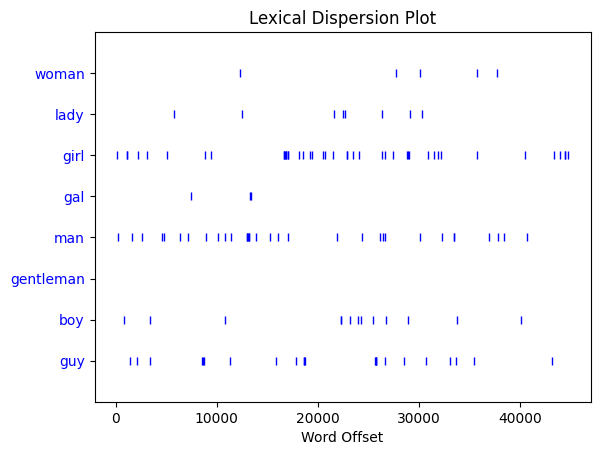

In [483]:
text5.dispersion_plot(
    ["woman", "lady", "girl", "gal", "man", "gentleman", "boy", "guy"]
)

### Gráfico de Dispersión en *Sense and Sensibility*

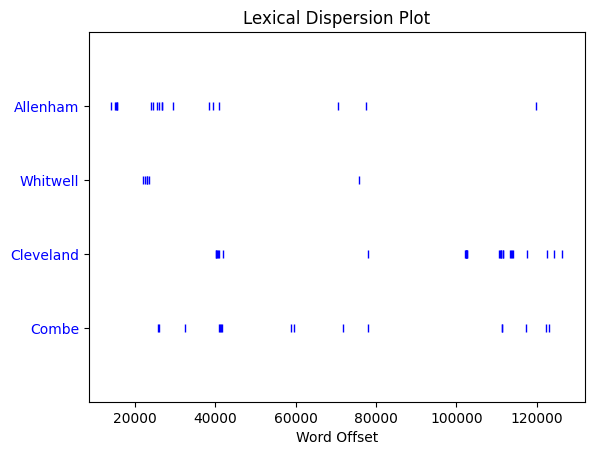

In [484]:
text2.dispersion_plot(["Allenham", "Whitwell", "Cleveland", "Combe"])

# Distribución de Frecuencia

In [485]:
from nltk import FreqDist
frequency_distribution = FreqDist(text5)

In [486]:
frequency_distribution = FreqDist(text5)
print(frequency_distribution)

<FreqDist with 6066 samples and 45010 outcomes>


In [487]:
# Visualizar las palabras más frecuentes,
#por ejemplo, las 20 más comunes:

frequency_distribution.most_common(20)


[('.', 1268),
 ('JOIN', 1021),
 ('PART', 1016),
 ('?', 737),
 ('lol', 704),
 ('to', 658),
 ('i', 648),
 ('the', 646),
 ('you', 635),
 (',', 596),
 ('I', 576),
 ('a', 568),
 ('hi', 546),
 ('me', 415),
 ('...', 412),
 ('is', 372),
 ('..', 361),
 ('in', 357),
 ('ACTION', 346),
 ('!', 342)]

## Eliminación de Stop Words y Distribución de Frecuencia

In [488]:
meaningful_words = [
    word for word in text5 if word.casefold() not in stop_words
]

In [492]:
# Se genera una nueva distribución de frecuencia basada únicamente en estas palabras:

frequency_distribution = FreqDist(meaningful_words)


# Se visualizan las 20 palabras más frecuentes dentro de esta lista filtrada:

frequency_distribution.most_common(20)



[('.', 1268),
 ('JOIN', 1021),
 ('PART', 1016),
 ('?', 737),
 ('lol', 704),
 ('i', 648),
 (',', 596),
 ('I', 576),
 ('hi', 546),
 ('...', 412),
 ('..', 361),
 ('ACTION', 346),
 ('!', 342),
 ('hey', 264),
 ('u', 200),
 ("'s", 195),
 ('not', 170),
 ('....', 170),
 ('like', 156),
 ('chat', 142)]

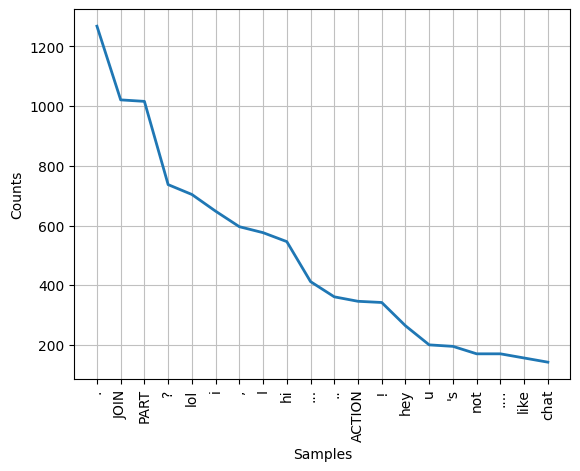

<Axes: xlabel='Samples', ylabel='Counts'>

In [493]:
# Visualización de la Distribución de Frecuencia

frequency_distribution.plot(20)

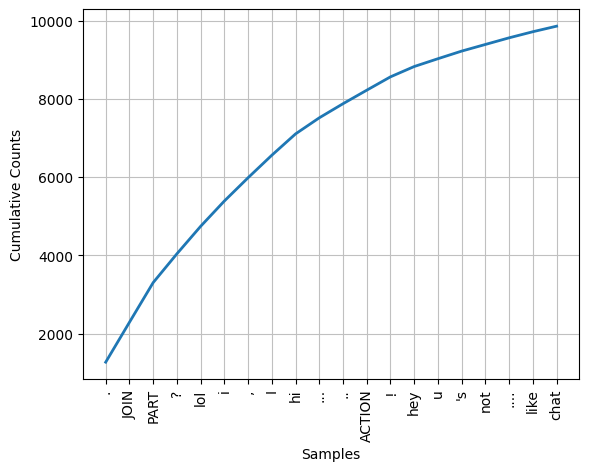

<Axes: xlabel='Samples', ylabel='Cumulative Counts'>

In [494]:
# Visualización de la distribución Acumulativa de Frecuencia
frequency_distribution.plot(20, cumulative=True)

# Colocaciones

In [491]:
text5.collocations()

wanna chat; PART JOIN; MODE #14-19teens; JOIN PART; PART PART;
cute.-ass MP3; MP3 player; JOIN JOIN; times .. .; ACTION watches; guys
wanna; song lasts; last night; ACTION sits; -...)...- S.M.R.; Lime
Player; Player 12%; dont know; lez gurls; long time


## lematización y Colación

In [495]:
lemmatized_words = [lemmatizer.lemmatize(word) for word in text8]

In [496]:
# Para aplicar los procesos lingüísticos es necesario construir un objeto Text de NLTK
new_text = nltk.Text(lemmatized_words)

In [497]:
new_text.collocations()

medium build; social drinker; non smoker; quiet night; long term;
would like; age open; easy going; financially secure; Would like; fun
time; similar interest; Age open; weekend away; well presented; never
married; single mum; permanent relationship; year old; slim build


# **Para profundizar**

> Para aprender más sobre análisis de sentimientos, consulte **Sentiment Analysis: First Steps With Python’s NLTK Library**:
> https://realpython.com/python-nltk-sentiment-analysis/.


#
<p style="font-size:300%; background-color:#ffe6f0; color:#0044cc; text-align:center; line-height:80px; margin:0; padding:0;">
  <b>BIBLIOTECA: speech_recognition</b>
</p>


In [499]:
import speech_recognition as sr

In [500]:
# Crear el reconocedor
recognizer = sr.Recognizer()

In [505]:
# Usar el micrófono como fuente de audio
with sr.Microphone() as source:
    print("Di algo...")
    recognizer.adjust_for_ambient_noise(source)
    audio = recognizer.listen(source)

ALSA lib pcm_dsnoop.c:567:(snd_pcm_dsnoop_open) unable to open slave
ALSA lib pcm_dmix.c:1000:(snd_pcm_dmix_open) unable to open slave
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.rear
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.center_lfe
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.side
ALSA lib pcm_dmix.c:1000:(snd_pcm_dmix_open) unable to open slave
Cannot connect to server socket err = No such file or directory
Cannot connect to server request channel
jack server is not running or cannot be started
JackShmReadWritePtr::~JackShmReadWritePtr - Init not done for -1, skipping unlock
JackShmReadWritePtr::~JackShmReadWritePtr - Init not done for -1, skipping unlock
ALSA lib pcm_dsnoop.c:567:(snd_pcm_dsnoop_open) unable to open slave
ALSA lib pcm_dmix.c:1000:(snd_pcm_dmix_open) unable to open slave
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.rear
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM c

Di algo...


In [506]:
# Intentar reconocer el audio
try:
    texto = recognizer.recognize_google(audio, language="es-ES")
    print("Dijiste:", texto)
except sr.UnknownValueError:
    print("No se entendió el audio.")
except sr.RequestError as e:
    print("Error al conectarse con el servicio:", e)

Dijiste: and Amazing Day
